# Random Forest

In [2]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from scipy.stats import linregress

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

base_path = '../data/all_sorted'
classes = ['BIC', 'CAR', 'HEAVY', 'MC']

## Pretprocesiranje i ekstrakcija znacajki

Ovo je identican pipeline kao u glavnoj EDA analizi (notch filter za mrezni hum + high-pass,
pa isti prosireni set znacajki bez `peak_frequency`) - kopiran ovdje radi izravne usporedivosti
rezultata izmedju modela, bez ponovnog objasnjavanja EDA dijela (taj je vec napravljen).

In [3]:
def remove_mains_hum(y, sr, hum_freqs=(50, 100, 150, 200), Q=30):
    """Uski notch filter na mreznoj frekvenciji i njenim harmonicima. Q=30 znaci vrlo uzak
    filter - makne samo usku vrpcu oko svake frekvencije, ne dira okolni spektar."""
    y_filt = y.copy()
    for f0 in hum_freqs:
        if f0 >= sr / 2:
            continue
        b, a = signal.iirnotch(f0, Q, sr)
        y_filt = signal.filtfilt(b, a, y_filt)
    return y_filt


def highpass(y, sr, cutoff=15, order=4):
    """Blagi high-pass da uklonimo vrlo niske frekvencije koje nam ne trebaju, koje mogu biti
    samo sum."""
    sos = signal.butter(order, cutoff, btype='highpass', fs=sr, output='sos')
    return signal.sosfiltfilt(sos, y)


def preprocess(y, sr):
    y = remove_mains_hum(y, sr)
    y = highpass(y, sr)
    return y

In [4]:
LOW_BAND = (0, 300)
MID_BAND = (300, 2000)
HIGH_BAND = (2000, 11025)


def fft_psd(y, sr):
    window = np.hanning(len(y))
    y_win = y * window

    fft = np.fft.rfft(y_win)
    psd = np.abs(fft) ** 2

    freqs = np.fft.rfftfreq(len(y), 1 / sr)
    return freqs, psd


def band_energy_ratios(freqs, psd):
    total = psd.sum() + 1e-12

    def band_frac(lo, hi):
        mask = (freqs >= lo) & (freqs < hi)
        return psd[mask].sum() / total

    return band_frac(*LOW_BAND), band_frac(*MID_BAND), band_frac(*HIGH_BAND)


def spectral_slope(freqs, psd, f_min=20, f_max=4000):
    mask = (freqs >= f_min) & (freqs <= f_max) & (psd > 0)
    if mask.sum() < 2:
        return 0.0
    log_f = np.log10(freqs[mask])
    log_p = np.log10(psd[mask])
    slope, _, _, _, _ = linregress(log_f, log_p)
    return slope


def bandwidth_low_band(freqs, psd):
    lo, hi = LOW_BAND
    mask = (freqs >= lo) & (freqs < hi)
    f = freqs[mask]
    p = psd[mask]
    if p.sum() <= 0:
        return 0.0
    centroid = np.average(f, weights=p)
    return np.sqrt(np.average((f - centroid) ** 2, weights=p))


def extract_features(y, sr):
    freqs, psd = fft_psd(y, sr)

    rms = np.mean(librosa.feature.rms(y=y))
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))
    centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    low_e, mid_e, high_e = band_energy_ratios(freqs, psd)
    slope = spectral_slope(freqs, psd)
    bw_low = bandwidth_low_band(freqs, psd)

    onset_env = librosa.onset.onset_strength(y=y, sr=sr)
    flux = np.abs(np.diff(onset_env))

    flatness = librosa.feature.spectral_flatness(y=y)[0]

    y_harm, y_perc = librosa.effects.hpss(y)
    harm_energy = np.sum(y_harm ** 2)
    perc_energy = np.sum(y_perc ** 2)
    harmonic_ratio = harm_energy / (harm_energy + perc_energy + 1e-12)

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=5)

    feats = {
        'rms': rms,
        'zcr': zcr,
        'spectral_centroid': centroid,
        'spectral_bandwidth': bandwidth,
        'spectral_rolloff': rolloff,
        'low_band_energy': low_e,
        'mid_band_energy': mid_e,
        'high_band_energy': high_e,
        'spectral_slope': slope,
        'bandwidth_low_band': bw_low,
        'flux_mean': np.mean(flux),
        'flux_std': np.std(flux),
        'spectral_flatness_mean': np.mean(flatness),
        'spectral_flatness_std': np.std(flatness),
        'harmonic_ratio': harmonic_ratio,
    }

    for i in range(5):
        feats[f'mfcc_{i}_mean'] = np.mean(mfcc[i])
        feats[f'mfcc_{i}_std'] = np.std(mfcc[i])

    return feats

In [5]:
CACHE_PATH = '../data/znacajke_cache.pkl'

if os.path.exists(CACHE_PATH):
    # Znacajke su vec izracunate i spremljene - samo ucitamo gotov DataFrame 
    df = pd.read_pickle(CACHE_PATH)
    print(f"Znacajke ucitane iz cachea: {CACHE_PATH} ({len(df)} uzoraka)")
else:
    data = []

    for label in classes:
        folder = os.path.join(base_path, label)
        files = [f for f in os.listdir(folder) if f.endswith('.wav')]

        for i, file in enumerate(files):
            path = os.path.join(folder, file)

            if i % 10 == 0:
                print(f"   {label}: {i}/{len(files)} -> {file}")

            y, sr = librosa.load(path, sr=None)
            y = y[:sr * 2]  # CLIP_SECONDS = 2
            y = preprocess(y, sr)

            feats = extract_features(y, sr)
            feats['label'] = label
            data.append(feats)

    print(f"\nGotovo! Ukupno uzoraka: {len(data)}")

    df = pd.DataFrame(data)
    df = df[[c for c in df.columns if c != 'label'] + ['label']]

    df.to_pickle(CACHE_PATH)
    print(f"Znacajke spremljene u cache: {CACHE_PATH}")

print("\nBroj uzoraka po klasi (provjera balansa):")
print(df['label'].value_counts())

X = df.drop(columns=['label'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

df.head()

Znacajke ucitane iz cachea: ../data/znacajke_cache.pkl (11391 uzoraka)

Broj uzoraka po klasi (provjera balansa):
label
CAR      9348
HEAVY    1190
MC        519
BIC       334
Name: count, dtype: int64


,rms,zcr,spectral_centroid,spectral_bandwidth,spectral_rolloff,low_band_energy,mid_band_energy,high_band_energy,spectral_slope,bandwidth_low_band,...,mfcc_0_std,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,mfcc_4_std,label
0,0.065307,0.019609,1826.503815,3078.726276,3590.425532,0.885687,0.101071,0.013052,-1.867504,45.903706,...,10.003626,178.775146,8.686232,-21.621541,5.821289,36.673271,4.580609,-1.047381,4.811483,BIC
1,0.035374,0.015698,2076.097549,4056.747926,4311.128657,0.971927,0.026018,0.001874,-2.311674,32.781818,...,22.649855,156.664657,11.681949,12.578587,7.050431,34.767883,6.372147,6.526522,8.544958,BIC
2,0.023371,0.036772,2588.184819,4263.899547,5891.040559,0.606855,0.378988,0.010833,-2.257224,65.991067,...,19.032952,167.932851,13.178547,2.001518,8.522644,37.542249,6.599697,-10.102805,7.831448,BIC
3,0.015145,0.041662,3539.687221,4993.381655,8676.861702,0.865271,0.112723,0.016721,-1.862074,42.518202,...,28.413603,140.353747,20.136714,-1.482174,10.328294,31.438115,6.909532,-8.179644,7.339408,BIC
4,0.005752,0.153959,4113.331616,4369.290481,9066.073803,0.322573,0.342152,0.329180,-1.000743,84.206649,...,13.254949,133.573605,16.001052,-39.154997,12.569525,36.705386,7.314667,-15.412616,6.875457,BIC


## 1. Teorijska podloga

### Sto je Random Forest?

Random Forest je **ensemble** metoda - umjesto jednog decision treeja (vidi prethodni notebook,
gdje smo pokazali da pojedinacno stablo ima visoku varijancu i sklono je overfittingu), trenira
se veliki broj stabala i njihove se predikcije **agregiraju** (za klasifikaciju: glasovanje
vecine) - [**VIDJETI izvor2**]

Dva izvora nasumicnosti cine "random" u imenu, oba kljucna za smanjenje korelacije izmedju
stabala (a time i varijance cijelog ansambla):

1. **Bagging** (bootstrap aggregating, **VIDJETI izvor3**) - svako stablo se trenira na drugom
   bootstrap uzorku (nasumicno uzorkovanje UZ vracanje) trening skupa, iste velicine kao
   originalni skup ali s ponavljanjima.
2. **Nasumican podskup znacajki po splitu** - za razliku od CART-a koji u svakom cvoru razmatra
   SVE znacajke za najbolji split, Random Forest u svakom cvoru razmatra samo nasumicni podskup
   (tipicno $\sqrt{p}$ znacajki za klasifikaciju, gdje je $p$ ukupan broj znacajki).


Breiman (2001) formalno pokazuje da generalizacijska greska sume stabala ovisi o dva faktora u
napetosti: **snazi (strength)** pojedinacnih stabala (koliko su tocna sama za sebe) i
**korelaciji** izmedju stabala (koliko slicne greske prave). Nasumicnost u odabiru znacajki
namjerno malo slabi pojedinacna stabla, ali puno vise smanjuje njihovu medusobnu korelaciju -
neto efekt je niza varijanca cijelog ansambla bez povecanja pristranosti (bias).

### Prednosti nad pojedinacnim stablom

- Puno robusniji na overfitting - usrednjavanje mnogo (namjerno oslabljenih, dekoreliranih)
  stabala smanjuje varijancu bez znacajnog povecanja pristranosti.
- **Out-of-bag (OOB) procjena greske** - buduci da svako stablo vidi samo  cca 63% podataka
  (bootstrap uzorak), preostalih cca 37% ("out-of-bag") moze se koristiti kao interna validacija
  bez odvajanja posebnog validacijskog skupa.
- I dalje daje feature importance, ali stabilniju (usrednjenu preko svih stabala) nego kod
  jednog stabla.

### Mane

- Manje interpretabilan od pojedinacnog stabla - ne moze se "pogledati" 300 stabala odjednom.
- Sporiji za treniranje i predikciju od jednog stabla (linearno s brojem stabala).
- `feature_importances_` (Gini-based) je poznato pristran prema znacajkama s vise moguchih
  vrijednosti (kontinuirane znacajke) - [VIDJETI izvor4] 
- `permutation_importance` (demonstrirano nize).

## 2. Primjena na dataset

Isti pristup kao u glavnoj analizi: `class_weight='balanced'`, `n_estimators=300`, isti
stratificirani train/test split.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)

train_acc = clf.score(X_train, y_train)
test_acc = clf.score(X_test, y_test)
print(f"Train accuracy: {train_acc:.3f}")
print(f"Test accuracy:  {test_acc:.3f}")
print(f"Razlika (train - test): {train_acc - test_acc:.3f}")
print("(Ocekivano bi trebala biti manja nego kod pojedinacnog neogranicenog stabla - to je\n"
      " direktna posljedica usrednjavanja u teoriji iznad. NEPOMENA: mora se gledati stablo nelimitirane dubine u prvom fileu\n" \
      "kada se tako gleda razlika kod decision_tree je 20%, a kod RF-a je 13%)")

Train accuracy: 1.000
Test accuracy:  0.867
Razlika (train - test): 0.132
(Ocekivano bi trebala biti manja nego kod pojedinacnog neogranicenog stabla - to je
 direktna posljedica usrednjavanja u teoriji iznad. NEPOMENA: mora se gledati stablo nelimitirane dubine u prvom fileu
kada se tako gleda razlika kod decision_tree je 20%, a kod RF-a je 13%)


              precision    recall  f1-score   support

         BIC       0.83      0.42      0.56        83
         CAR       0.87      0.98      0.93      2337
       HEAVY       0.76      0.35      0.48       298
          MC       0.78      0.25      0.37       130

    accuracy                           0.87      2848
   macro avg       0.81      0.50      0.59      2848
weighted avg       0.86      0.87      0.84      2848



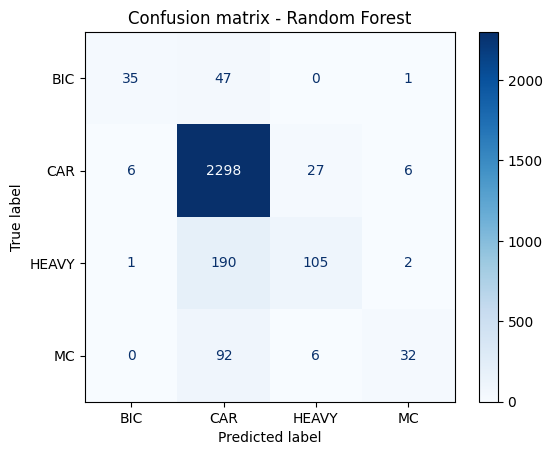

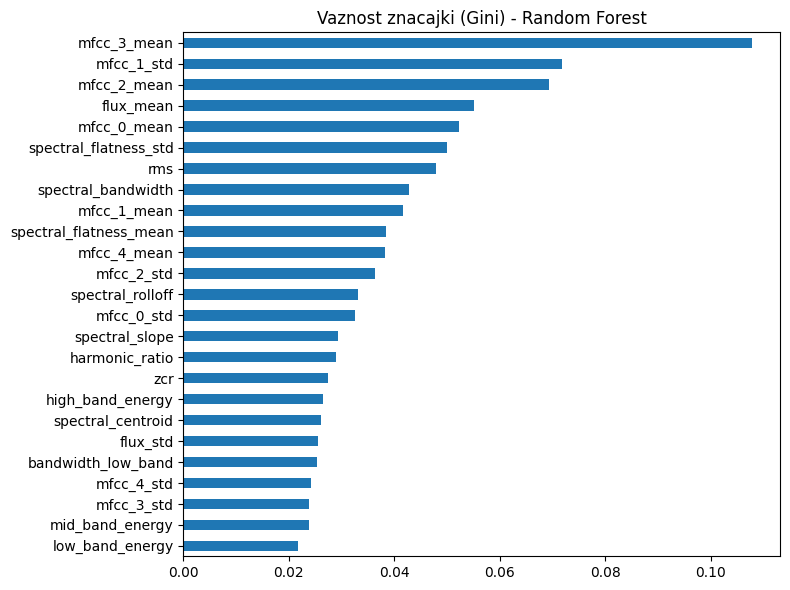

In [7]:
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion matrix - Random Forest')
plt.show()

importances = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
importances.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Vaznost znacajki (Gini) - Random Forest')
plt.tight_layout()
plt.show()

### Pouzdanija vaznost znacajki: permutation importance

Gini-based `feature_importances_` moze precijeniti kontinuirane znacajke. Permutation
importance mjeri koliko tocnost PADNE kad se vrijednosti jedne znacajke nasumicno izmijesaju
(permutiraju) na test skupu - izravnija, manje pristrana mjera, ali sporija za racunati.

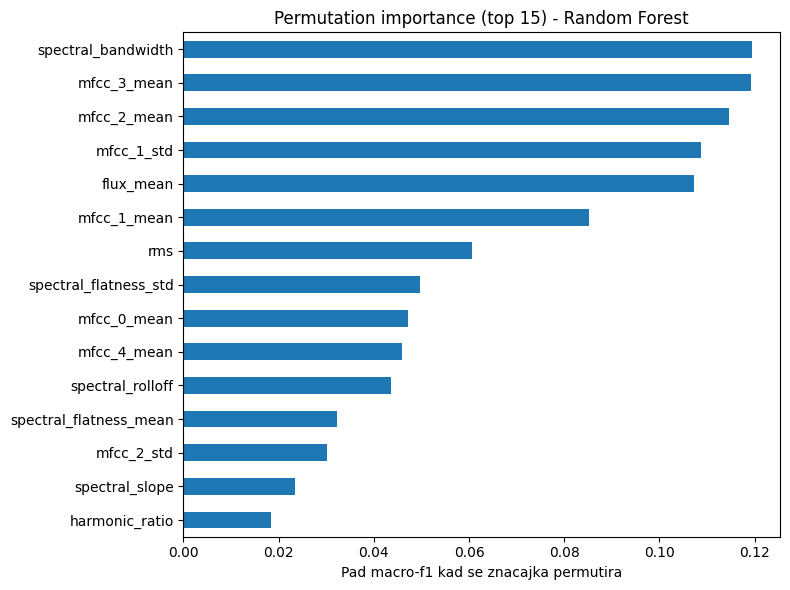

Usporedjeno sa grafom gore - ako se poredak bitno razlikuje,
Gini verzija je vjerojatno precijenila neke kontinuirane znacajke.
doduse ovo je dosta slican popis kao ovaj gore, samo je mozda Gini malo precijenio neke znacajke


In [9]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(clf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1, scoring='f1_macro')

perm_importances = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
perm_importances.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Permutation importance (top 15) - Random Forest')
plt.xlabel('Pad macro-f1 kad se znacajka permutira')
plt.tight_layout()
plt.show()

print("Usporedjeno sa grafom gore - ako se poredak bitno razlikuje,\n"
      "Gini verzija je vjerojatno precijenila neke kontinuirane znacajke.\n"
      "doduse ovo je dosta slican popis kao ovaj gore, samo je mozda Gini malo precijenio neke znacajke")

## 3. Zakljucak

Random Forest je pokazao manju razliku train/test tocnosti nego pojedinacno stablo
(manje overfitta), ali slican (malo bolji) macro-f1 kao jedno dobro regulirano stablo - glavni
dobitak Random Foresta nije nuzno visi vrh performanse, nego **stabilnost** (manja varijanca
rezultata). Za stvarni pomak u macro-f1 (posebno recall na BIC/HEAVY/MC koji je gori nego na DecisionTree) vjerojatno treba
jace rjesavanje neravnoteze klasa (oversampling) ili XGBoost (sljedeci notebook), ne samo
promjena modela unutar iste "bagging" obitelji.